# Importando Bibliotecas

In [5]:
# Acesso e edição de matrizes
import numpy as np
import pandas as pd

# Salva os objetos
from joblib import dump, load

# Desenho de gráficos
import matplotlib.pyplot as plt

# Edita balanceamento de variáveis
# from imblearn.over_sampling import SMOTE

# Executa comandos do sistema operacional
import subprocess as sp

# Acessa variáveis de ambiente
import os
try:
    os.chdir("aulas_teoricas")
except FileNotFoundError:
    pass

# Gerando a DataFrame de Trabalho

In [7]:
# Numero de linhas no arquivo de palavras
num_palavras = sp.run(["wc", "-l", "./data/palavras.txt"], capture_output=True, text=True)
num_palavras = num_palavras.stdout.strip()
num_palavras = int(num_palavras.split()[0])
num_palavras

235969

In [8]:
def ler_linha_especifica(nome_arquivo: str, numero_linha: int) -> str | None:
    '''
        Lê uma linha específica de um arquivo. 
        
        :param nome_arquivo: Caminho para o arquivo.
        :param numero_linha: Número da linha a ser lida (0-indexado).
        :return: Conteúdo da linha ou None se a linha não existir.
    '''
    with open(nome_arquivo, 'r') as f:
        for indice, linha in enumerate(f):
            if indice == numero_linha:
                return linha.strip()
    return None

In [9]:
# Lista com categorias ordinais
ordinal = ["micro", "mini", "midi", "maxi"]
ordinal

['micro', 'mini', 'midi', 'maxi']

In [10]:
def nova_df(n: int = 1_000) -> dict:
    '''
        Gera um dicionário com 4 variáveis:
            - num_cont: variável numérica contínua
            - num_disc: variável numérica discreta
            - cat_nomi: variável categórica nominal
            - cat_ordi: variável categórica ordinal
            
        :param n: número de linhas a serem geradas (padrão é 1000)
        :return: dicionário com as variáveis
    '''
    # Para reprodutibilidade
    np.random.seed(42)
    
    # Variável numérica contínua
    num_cont = np.random.normal(1, 2, n)
    num_cont[(num_cont >= 1.35) & (num_cont <= 1.45)] = np.nan

    # Variável numérica discréta
    num_disc = np.random.normal(1, 2, n)//1
    num_disc = np.where(num_disc == 0, 'nan', num_disc)
    
    # Variável categórica nominal
    cat_nomi = np.random.randint(1, num_palavras, size=n)
    cat_nomi = [ler_linha_especifica('./data/palavras.txt', i) for i in cat_nomi]
    
    # Variável categórica ordinal
    cat_ordi = [ordinal[np.random.randint(len(ordinal))] for _ in range(n)]
    
    # Dicionário organizando as variáveis
    resultado = {
        'num_cont': num_cont,
        'num_disc': num_disc,
        'cat_nomi': cat_nomi,
        'cat_ordi': cat_ordi,
    }
    return resultado

In [11]:
# Instantiando o DataFrame
df_gera = pd.DataFrame(nova_df())
df_gera.head()

,num_cont,num_disc,cat_nomi,cat_ordi
0,1.993428,3.0,anhalouidine,midi
1,0.723471,2.0,joke,maxi
2,2.295377,1.0,orthobiosis,maxi
3,4.046060,-1.0,takedown,micro
4,0.531693,2.0,becrimson,midi


In [12]:
# Salva DataFrame. 
# dump(df_gera, './data/04_aula_df_gera')

# Carrega DataFrame.
df = load('./data/04_aula_df_gera')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   num_cont  970 non-null    float64
 1   num_disc  1000 non-null   object 
 2   cat_nomi  1000 non-null   object 
 3   cat_ordi  1000 non-null   object 
dtypes: float64(1), object(3)
memory usage: 31.4+ KB


# Tratando variáveis

## Substituindo faltantes

In [13]:
# Verificando valores faltantes
df.isna().sum()

num_cont    30
num_disc     0
cat_nomi     0
cat_ordi     0
dtype: int64

In [14]:
# Quantificando as entradas na variável num_disc
df.num_disc.value_counts().head()

nan     199
1.0     191
2.0     156
-1.0    139
3.0      96
Name: num_disc, dtype: int64

In [15]:
# Selecionando entradas com "nan" em num_disc
df[df.num_disc == "nan"].head()

,num_cont,num_disc,cat_nomi,cat_ordi
17,1.628495,nan,Theresa,maxi
18,-0.816048,nan,guiltiness,maxi
22,1.135056,nan,hyphedonia,micro
30,-0.203413,nan,antimissionary,midi
34,2.645090,nan,Pleuronectes,mini


In [16]:
# Substituindo 'nan' por np.nan, usando a função replace
df.num_disc = df.num_disc.replace('nan', np.nan)

# Selecionando entradas com "nan" em num_disc
df[df.num_disc == "nan"].head()

,num_cont,num_disc,cat_nomi,cat_ordi


In [17]:
# Verificando valores faltantes
df.isna().sum()

num_cont     30
num_disc    199
cat_nomi      0
cat_ordi      0
dtype: int64

In [18]:
# Veririfcando as informações da df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   num_cont  970 non-null    float64
 1   num_disc  801 non-null    object 
 2   cat_nomi  1000 non-null   object 
 3   cat_ordi  1000 non-null   object 
dtypes: float64(1), object(3)
memory usage: 31.4+ KB


In [19]:
# Tentando converter a variável discreta para int64
try:
    df.num_disc = df.num_disc.astype('int64')
    display(df.info())
except Exception as e:
    print(f"Erro ao converter para int64: {e}")

Erro ao converter para int64: invalid literal for int() with base 10: '3.0'


In [20]:
# Convertendo para float
df.num_disc = df.num_disc.astype('float')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   num_cont  970 non-null    float64
 1   num_disc  801 non-null    float64
 2   cat_nomi  1000 non-null   object 
 3   cat_ordi  1000 non-null   object 
dtypes: float64(2), object(2)
memory usage: 31.4+ KB


In [21]:
# Analisando medidas resumo
df.describe()

,num_cont,num_disc
count,970.000000,801.000000
mean,1.027406,0.805243
std,1.987447,2.241545
min,-5.482535,-5.000000
25%,-0.345900,-1.000000
50%,0.965064,1.000000
75%,2.335574,2.000000
max,8.705463,7.000000


In [22]:
# Obtendo a mediana da variáveç discreta
np.median(df.num_disc)

nan

In [23]:
# Obtendo a mediana da variáveç discreta
np.median(df.num_disc.dropna())

1.0

In [24]:
# Tentando converter a variável discreta para int64
try:
    df.num_disc = df.num_disc.astype('int64')
    display(df.info())
except Exception as e:
    print(f"Erro ao converter para int64: {e}")

Erro ao converter para int64: Cannot convert non-finite values (NA or inf) to integer


In [25]:
# Preenchendo valores faltantes com a mediana
df.num_disc.fillna(np.median(df.num_disc.dropna()), inplace=True)

# Tentando converter a variável discreta para int64
try:
    df.num_disc = df.num_disc.astype('int64')
    display(df.info())
except Exception as e:
    print(f"Erro ao converter para int64: {e}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   num_cont  970 non-null    float64
 1   num_disc  1000 non-null   int64  
 2   cat_nomi  1000 non-null   object 
 3   cat_ordi  1000 non-null   object 
dtypes: float64(1), int64(1), object(2)
memory usage: 31.4+ KB


None

In [26]:
# Verificando informações após remoção de NaNs
df.dropna().info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 970 entries, 0 to 999
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   num_cont  970 non-null    float64
 1   num_disc  970 non-null    int64  
 2   cat_nomi  970 non-null    object 
 3   cat_ordi  970 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 37.9+ KB


In [27]:
# Verificando as informações após remoção de duplicatas na variável contínua
df.iloc[df.num_cont.drop_duplicates().index, :].info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 971 entries, 0 to 999
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   num_cont  970 non-null    float64
 1   num_disc  971 non-null    int64  
 2   cat_nomi  971 non-null    object 
 3   cat_ordi  971 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 37.9+ KB


In [28]:
# Verificando completar faltantes com o próximo valor válido
df.bfill().info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   num_cont  1000 non-null   float64
 1   num_disc  1000 non-null   int64  
 2   cat_nomi  1000 non-null   object 
 3   cat_ordi  1000 non-null   object 
dtypes: float64(1), int64(1), object(2)
memory usage: 31.4+ KB


In [29]:
# Verificando medidas resumo após completar faltantes com o próximo valor válido
display(df.describe())
display(df.bfill().describe())

,num_cont,num_disc
count,970.000000,1000.00000
mean,1.027406,0.84400
std,1.987447,2.00741
min,-5.482535,-5.00000
25%,-0.345900,-1.00000
50%,0.965064,1.00000
75%,2.335574,2.00000
max,8.705463,7.00000


,num_cont,num_disc
count,1000.000000,1000.00000
mean,1.010748,0.84400
std,1.984657,2.00741
min,-5.482535,-5.00000
25%,-0.355755,-1.00000
50%,0.960082,1.00000
75%,2.314103,2.00000
max,8.705463,7.00000


In [30]:
# Instanciando um novo DataFrame com os valores faltantes preenchidos
df_no_nan = df.bfill()
df_no_nan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   num_cont  1000 non-null   float64
 1   num_disc  1000 non-null   int64  
 2   cat_nomi  1000 non-null   object 
 3   cat_ordi  1000 non-null   object 
dtypes: float64(1), int64(1), object(2)
memory usage: 31.4+ KB


In [31]:
# Salva DataFrame. 
# dump(df_no_nan, './data/04_aula_df_no_nan')

# Carrega DataFrame.
df = load('./data/04_aula_df_no_nan')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   num_cont  1000 non-null   float64
 1   num_disc  1000 non-null   int64  
 2   cat_nomi  1000 non-null   object 
 3   cat_ordi  1000 non-null   object 
dtypes: float64(1), int64(1), object(2)
memory usage: 31.4+ KB


## Transformação a variável categórica em variáveis lógicas

In [32]:
# Verificando variáveis categóricas
df[['cat_ordi', 'cat_nomi']].describe()

,cat_ordi,cat_nomi
count,1000,1000
unique,4,1000
top,midi,anhalouidine
freq,259,1


In [33]:
# Convertendo variáveis categóricas em variáveis dummy
pd.get_dummies(df, columns=['cat_ordi', 'cat_nomi']).head()

,num_cont,num_disc,cat_ordi_maxi,cat_ordi_micro,cat_ordi_midi,cat_ordi_mini,cat_nomi_Abelite,cat_nomi_Achaean,cat_nomi_Adolphus,cat_nomi_Agathis,...,cat_nomi_xiphoidal,cat_nomi_yeat,cat_nomi_yeni,cat_nomi_yok,cat_nomi_zamarro,cat_nomi_zither,cat_nomi_zogo,cat_nomi_zoomelanin,cat_nomi_zucchini,cat_nomi_zumatic
0,1.993428,3,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0.723471,2,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2.295377,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4.046060,-1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0.531693,2,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [34]:
# Convertendo variáveis categóricas em variáveis dummy
df_dummies = pd.get_dummies(df, columns=['cat_ordi'])
df_dummies.head()

,num_cont,num_disc,cat_nomi,cat_ordi_maxi,cat_ordi_micro,cat_ordi_midi,cat_ordi_mini
0,1.993428,3,anhalouidine,0,0,1,0
1,0.723471,2,joke,1,0,0,0
2,2.295377,1,orthobiosis,1,0,0,0
3,4.046060,-1,takedown,0,1,0,0
4,0.531693,2,becrimson,0,0,1,0


## Transformando a variável nominal

In [35]:
# Varificando quantas entradas únicas existem na variável nominal
len(df_dummies.cat_nomi.unique())

1000

In [36]:
# Informações da df_dummies
df_dummies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   num_cont        1000 non-null   float64
 1   num_disc        1000 non-null   int64  
 2   cat_nomi        1000 non-null   object 
 3   cat_ordi_maxi   1000 non-null   uint8  
 4   cat_ordi_micro  1000 non-null   uint8  
 5   cat_ordi_midi   1000 non-null   uint8  
 6   cat_ordi_mini   1000 non-null   uint8  
dtypes: float64(1), int64(1), object(1), uint8(4)
memory usage: 27.5+ KB


In [37]:
# Verificando o tamanho das strings na variável nominal
df_dummies.cat_nomi.apply(len).head()

0    12
1     4
2    11
3     8
4     9
Name: cat_nomi, dtype: int64

In [38]:
# Inserindo nova variável com o tamanho das strings na variável nominal
df_dummies['cat_nomi_len'] = df_dummies.cat_nomi.apply(len)
df_dummies.head()

,num_cont,num_disc,cat_nomi,cat_ordi_maxi,cat_ordi_micro,cat_ordi_midi,cat_ordi_mini,cat_nomi_len
0,1.993428,3,anhalouidine,0,0,1,0,12
1,0.723471,2,joke,1,0,0,0,4
2,2.295377,1,orthobiosis,1,0,0,0,11
3,4.046060,-1,takedown,0,1,0,0,8
4,0.531693,2,becrimson,0,0,1,0,9


In [39]:
# Informações da df_dummies
df_dummies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   num_cont        1000 non-null   float64
 1   num_disc        1000 non-null   int64  
 2   cat_nomi        1000 non-null   object 
 3   cat_ordi_maxi   1000 non-null   uint8  
 4   cat_ordi_micro  1000 non-null   uint8  
 5   cat_ordi_midi   1000 non-null   uint8  
 6   cat_ordi_mini   1000 non-null   uint8  
 7   cat_nomi_len    1000 non-null   int64  
dtypes: float64(1), int64(2), object(1), uint8(4)
memory usage: 35.3+ KB


In [40]:
# Reordenando as colunas
df_dummies = df_dummies.iloc[:, [0, 1, 3, 4, 5, 6, 2, 7]]
df_dummies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   num_cont        1000 non-null   float64
 1   num_disc        1000 non-null   int64  
 2   cat_ordi_maxi   1000 non-null   uint8  
 3   cat_ordi_micro  1000 non-null   uint8  
 4   cat_ordi_midi   1000 non-null   uint8  
 5   cat_ordi_mini   1000 non-null   uint8  
 6   cat_nomi        1000 non-null   object 
 7   cat_nomi_len    1000 non-null   int64  
dtypes: float64(1), int64(2), object(1), uint8(4)
memory usage: 35.3+ KB


In [41]:
# Descrição da nova variável
df_dummies.cat_nomi_len.describe()

count    1000.000000
mean        9.405000
std         2.922587
min         2.000000
25%         7.000000
50%         9.000000
75%        11.000000
max        19.000000
Name: cat_nomi_len, dtype: float64

In [42]:
# Verificando os valores categorizados pelos quantiles
pd.qcut(x=df_dummies.cat_nomi_len, q=4, labels=["min", "25%", "50%", "75%"]).head()

0    75%
1    min
2    50%
3    25%
4    25%
Name: cat_nomi_len, dtype: category
Categories (4, object): ['min' < '25%' < '50%' < '75%']

In [43]:
# Inserindo nova variável com os quantiles
cat_nomi_len_qcut = pd.qcut(x=df_dummies.cat_nomi_len, q=4, labels=["min", "25%", "50%", "75%"])

df_dummies.drop(["cat_nomi_len"], axis=1, inplace=True)

df_dummies_qcut = df_dummies.copy()
df_dummies_qcut.loc[:, 'cat_nomi_len_qcut'] = cat_nomi_len_qcut
df_dummies_qcut.head()

,num_cont,num_disc,cat_ordi_maxi,cat_ordi_micro,cat_ordi_midi,cat_ordi_mini,cat_nomi,cat_nomi_len_qcut
0,1.993428,3,0,0,1,0,anhalouidine,75%
1,0.723471,2,1,0,0,0,joke,min
2,2.295377,1,1,0,0,0,orthobiosis,50%
3,4.046060,-1,0,1,0,0,takedown,25%
4,0.531693,2,0,0,1,0,becrimson,25%


In [44]:
# Convertendo variáveis categóricas em variáveis dummy
df_dummies_qcut = pd.get_dummies(df_dummies_qcut, columns=['cat_nomi_len_qcut'])
df_dummies_qcut.head()

,num_cont,num_disc,cat_ordi_maxi,cat_ordi_micro,cat_ordi_midi,cat_ordi_mini,cat_nomi,cat_nomi_len_qcut_min,cat_nomi_len_qcut_25%,cat_nomi_len_qcut_50%,cat_nomi_len_qcut_75%
0,1.993428,3,0,0,1,0,anhalouidine,0,0,0,1
1,0.723471,2,1,0,0,0,joke,1,0,0,0
2,2.295377,1,1,0,0,0,orthobiosis,0,0,1,0
3,4.046060,-1,0,1,0,0,takedown,0,1,0,0
4,0.531693,2,0,0,1,0,becrimson,0,1,0,0


In [45]:
# Salva DataFrame.
# dump(df_dummies_qcut, './data/04_aula_df_dummies_qcut')

# Carrega DataFrame.
df = load('./data/04_aula_df_dummies_qcut')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_cont               1000 non-null   float64
 1   num_disc               1000 non-null   int64  
 2   cat_ordi_maxi          1000 non-null   uint8  
 3   cat_ordi_micro         1000 non-null   uint8  
 4   cat_ordi_midi          1000 non-null   uint8  
 5   cat_ordi_mini          1000 non-null   uint8  
 6   cat_nomi               1000 non-null   object 
 7   cat_nomi_len_qcut_min  1000 non-null   uint8  
 8   cat_nomi_len_qcut_25%  1000 non-null   uint8  
 9   cat_nomi_len_qcut_50%  1000 non-null   uint8  
 10  cat_nomi_len_qcut_75%  1000 non-null   uint8  
dtypes: float64(1), int64(1), object(1), uint8(8)
memory usage: 31.4+ KB


## Concatenando DataFrames

In [46]:
# Verifica a DataFrame
df.head()

,num_cont,num_disc,cat_ordi_maxi,cat_ordi_micro,cat_ordi_midi,cat_ordi_mini,cat_nomi,cat_nomi_len_qcut_min,cat_nomi_len_qcut_25%,cat_nomi_len_qcut_50%,cat_nomi_len_qcut_75%
0,1.993428,3,0,0,1,0,anhalouidine,0,0,0,1
1,0.723471,2,1,0,0,0,joke,1,0,0,0
2,2.295377,1,1,0,0,0,orthobiosis,0,0,1,0
3,4.046060,-1,0,1,0,0,takedown,0,1,0,0
4,0.531693,2,0,0,1,0,becrimson,0,1,0,0


In [47]:
# Cria a variável cat_nomi1, copiando a cat_nomi
df.loc[:, "cat_nomi1"] = df['cat_nomi']

# Renomeia a variável cat_nomi para cat_nome2
df.rename(columns={"cat_nomi": "cat_nomi2"}, inplace=True)
df.head()

,num_cont,num_disc,cat_ordi_maxi,cat_ordi_micro,cat_ordi_midi,cat_ordi_mini,cat_nomi2,cat_nomi_len_qcut_min,cat_nomi_len_qcut_25%,cat_nomi_len_qcut_50%,cat_nomi_len_qcut_75%,cat_nomi1
0,1.993428,3,0,0,1,0,anhalouidine,0,0,0,1,anhalouidine
1,0.723471,2,1,0,0,0,joke,1,0,0,0,joke
2,2.295377,1,1,0,0,0,orthobiosis,0,0,1,0,orthobiosis
3,4.046060,-1,0,1,0,0,takedown,0,1,0,0,takedown
4,0.531693,2,0,0,1,0,becrimson,0,1,0,0,becrimson


In [48]:
# Seleciona as colunas para dois novos DataFrames
colunas_df1 = [
    'cat_nomi1',
    'cat_ordi_micro',
    'cat_ordi_midi',
    'cat_ordi_mini',
]

colunas_df2 = [
    'cat_nomi2',
    'cat_nomi_len_qcut_25%',
    'cat_nomi_len_qcut_50%',
    'cat_nomi_len_qcut_75%',
]
display(colunas_df1)
display(colunas_df2)

['cat_nomi1', 'cat_ordi_micro', 'cat_ordi_midi', 'cat_ordi_mini']

['cat_nomi2',
 'cat_nomi_len_qcut_25%',
 'cat_nomi_len_qcut_50%',
 'cat_nomi_len_qcut_75%']

In [49]:
# Instancia a df1 com as primeiras variáveis de df
#  e renomeia o cat_nome1 para id
df1 = df[colunas_df1].head().copy()
df1.rename(columns={"cat_nomi1": "id"}, inplace=True)

# Instancia a df2 com as primeiras variáveis de df
#  e renomeia o cat_nome2 para id
df2 = df[colunas_df2].head().copy()
df2.rename(columns={"cat_nomi2": "id"}, inplace=True)

display(df1)
display(df2)

,id,cat_ordi_micro,cat_ordi_midi,cat_ordi_mini
0,anhalouidine,0,1,0
1,joke,0,0,0
2,orthobiosis,0,0,0
3,takedown,1,0,0
4,becrimson,0,1,0


,id,cat_nomi_len_qcut_25%,cat_nomi_len_qcut_50%,cat_nomi_len_qcut_75%
0,anhalouidine,0,0,1
1,joke,0,0,0
2,orthobiosis,0,1,0
3,takedown,1,0,0
4,becrimson,1,0,0


### Merge

#### Full

In [50]:
df1.merge(df2, on="id", how="left")

,id,cat_ordi_micro,cat_ordi_midi,cat_ordi_mini,cat_nomi_len_qcut_25%,cat_nomi_len_qcut_50%,cat_nomi_len_qcut_75%
0,anhalouidine,0,1,0,0,0,1
1,joke,0,0,0,0,0,0
2,orthobiosis,0,0,0,0,1,0
3,takedown,1,0,0,1,0,0
4,becrimson,0,1,0,1,0,0


In [51]:
df1.merge(df2, on="id", how="right")

,id,cat_ordi_micro,cat_ordi_midi,cat_ordi_mini,cat_nomi_len_qcut_25%,cat_nomi_len_qcut_50%,cat_nomi_len_qcut_75%
0,anhalouidine,0,1,0,0,0,1
1,joke,0,0,0,0,0,0
2,orthobiosis,0,0,0,0,1,0
3,takedown,1,0,0,1,0,0
4,becrimson,0,1,0,1,0,0


In [52]:
df1.merge(df2, on="id", how="inner")

,id,cat_ordi_micro,cat_ordi_midi,cat_ordi_mini,cat_nomi_len_qcut_25%,cat_nomi_len_qcut_50%,cat_nomi_len_qcut_75%
0,anhalouidine,0,1,0,0,0,1
1,joke,0,0,0,0,0,0
2,orthobiosis,0,0,0,0,1,0
3,takedown,1,0,0,1,0,0
4,becrimson,0,1,0,1,0,0


In [53]:
df1.merge(df2, on="id", how="outer")

,id,cat_ordi_micro,cat_ordi_midi,cat_ordi_mini,cat_nomi_len_qcut_25%,cat_nomi_len_qcut_50%,cat_nomi_len_qcut_75%
0,anhalouidine,0,1,0,0,0,1
1,joke,0,0,0,0,0,0
2,orthobiosis,0,0,0,0,1,0
3,takedown,1,0,0,1,0,0
4,becrimson,0,1,0,1,0,0


#### Menos linha 4

In [54]:
df2_sem4 = df2.loc[:3, :].copy()
display(df1)
display(df2_sem4)

,id,cat_ordi_micro,cat_ordi_midi,cat_ordi_mini
0,anhalouidine,0,1,0
1,joke,0,0,0
2,orthobiosis,0,0,0
3,takedown,1,0,0
4,becrimson,0,1,0


,id,cat_nomi_len_qcut_25%,cat_nomi_len_qcut_50%,cat_nomi_len_qcut_75%
0,anhalouidine,0,0,1
1,joke,0,0,0
2,orthobiosis,0,1,0
3,takedown,1,0,0


In [55]:
df1.merge(df2_sem4, on="id", how="left")

,id,cat_ordi_micro,cat_ordi_midi,cat_ordi_mini,cat_nomi_len_qcut_25%,cat_nomi_len_qcut_50%,cat_nomi_len_qcut_75%
0,anhalouidine,0,1,0,0.0,0.0,1.0
1,joke,0,0,0,0.0,0.0,0.0
2,orthobiosis,0,0,0,0.0,1.0,0.0
3,takedown,1,0,0,1.0,0.0,0.0
4,becrimson,0,1,0,NaN,NaN,NaN


In [56]:
df1.merge(df2_sem4, on="id", how="right")

,id,cat_ordi_micro,cat_ordi_midi,cat_ordi_mini,cat_nomi_len_qcut_25%,cat_nomi_len_qcut_50%,cat_nomi_len_qcut_75%
0,anhalouidine,0,1,0,0,0,1
1,joke,0,0,0,0,0,0
2,orthobiosis,0,0,0,0,1,0
3,takedown,1,0,0,1,0,0


In [57]:
df1.merge(df2_sem4, on="id", how="inner")

,id,cat_ordi_micro,cat_ordi_midi,cat_ordi_mini,cat_nomi_len_qcut_25%,cat_nomi_len_qcut_50%,cat_nomi_len_qcut_75%
0,anhalouidine,0,1,0,0,0,1
1,joke,0,0,0,0,0,0
2,orthobiosis,0,0,0,0,1,0
3,takedown,1,0,0,1,0,0


In [58]:
df1.merge(df2_sem4, on="id", how="outer")

,id,cat_ordi_micro,cat_ordi_midi,cat_ordi_mini,cat_nomi_len_qcut_25%,cat_nomi_len_qcut_50%,cat_nomi_len_qcut_75%
0,anhalouidine,0,1,0,0.0,0.0,1.0
1,joke,0,0,0,0.0,0.0,0.0
2,orthobiosis,0,0,0,0.0,1.0,0.0
3,takedown,1,0,0,1.0,0.0,0.0
4,becrimson,0,1,0,NaN,NaN,NaN


#### Menos linha 4 e linha 3

In [59]:
df1_sem3 = df1.loc[[0,1,2,4], :]
display(df1_sem3)
display(df2_sem4)

,id,cat_ordi_micro,cat_ordi_midi,cat_ordi_mini
0,anhalouidine,0,1,0
1,joke,0,0,0
2,orthobiosis,0,0,0
4,becrimson,0,1,0


,id,cat_nomi_len_qcut_25%,cat_nomi_len_qcut_50%,cat_nomi_len_qcut_75%
0,anhalouidine,0,0,1
1,joke,0,0,0
2,orthobiosis,0,1,0
3,takedown,1,0,0


In [60]:
df1_sem3.merge(df2_sem4, on="id", how="left")

,id,cat_ordi_micro,cat_ordi_midi,cat_ordi_mini,cat_nomi_len_qcut_25%,cat_nomi_len_qcut_50%,cat_nomi_len_qcut_75%
0,anhalouidine,0,1,0,0.0,0.0,1.0
1,joke,0,0,0,0.0,0.0,0.0
2,orthobiosis,0,0,0,0.0,1.0,0.0
3,becrimson,0,1,0,NaN,NaN,NaN


In [61]:
df1_sem3.merge(df2_sem4, on="id", how="right")

,id,cat_ordi_micro,cat_ordi_midi,cat_ordi_mini,cat_nomi_len_qcut_25%,cat_nomi_len_qcut_50%,cat_nomi_len_qcut_75%
0,anhalouidine,0.0,1.0,0.0,0,0,1
1,joke,0.0,0.0,0.0,0,0,0
2,orthobiosis,0.0,0.0,0.0,0,1,0
3,takedown,NaN,NaN,NaN,1,0,0


In [62]:
df1_sem3.merge(df2_sem4, on="id", how="inner")

,id,cat_ordi_micro,cat_ordi_midi,cat_ordi_mini,cat_nomi_len_qcut_25%,cat_nomi_len_qcut_50%,cat_nomi_len_qcut_75%
0,anhalouidine,0,1,0,0,0,1
1,joke,0,0,0,0,0,0
2,orthobiosis,0,0,0,0,1,0


In [63]:
df1_sem3.merge(df2_sem4, on="id", how="outer")

,id,cat_ordi_micro,cat_ordi_midi,cat_ordi_mini,cat_nomi_len_qcut_25%,cat_nomi_len_qcut_50%,cat_nomi_len_qcut_75%
0,anhalouidine,0.0,1.0,0.0,0.0,0.0,1.0
1,joke,0.0,0.0,0.0,0.0,0.0,0.0
2,orthobiosis,0.0,0.0,0.0,0.0,1.0,0.0
3,becrimson,0.0,1.0,0.0,NaN,NaN,NaN
4,takedown,NaN,NaN,NaN,1.0,0.0,0.0


### Concat

#### Linhas

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_cont               1000 non-null   float64
 1   num_disc               1000 non-null   int64  
 2   cat_ordi_maxi          1000 non-null   uint8  
 3   cat_ordi_micro         1000 non-null   uint8  
 4   cat_ordi_midi          1000 non-null   uint8  
 5   cat_ordi_mini          1000 non-null   uint8  
 6   cat_nomi2              1000 non-null   object 
 7   cat_nomi_len_qcut_min  1000 non-null   uint8  
 8   cat_nomi_len_qcut_25%  1000 non-null   uint8  
 9   cat_nomi_len_qcut_50%  1000 non-null   uint8  
 10  cat_nomi_len_qcut_75%  1000 non-null   uint8  
 11  cat_nomi1              1000 non-null   object 
dtypes: float64(1), int64(1), object(2), uint8(8)
memory usage: 39.2+ KB


In [65]:
df1 = df.iloc[:5, :4].copy()
df2 = df.iloc[-5:, :4].copy()
df2.index = df1.index

display(df1)
display(df2)

,num_cont,num_disc,cat_ordi_maxi,cat_ordi_micro
0,1.993428,3,0,0
1,0.723471,2,1,0
2,2.295377,1,1,0
3,4.046060,-1,0,1
4,0.531693,2,0,0


,num_cont,num_disc,cat_ordi_maxi,cat_ordi_micro
0,0.437799,3,0,1
1,4.595373,1,0,0
2,2.281686,-1,0,0
3,-0.142358,1,1,0
4,2.145166,-1,0,0


In [66]:
pd.concat([df1, df2], axis='rows')

,num_cont,num_disc,cat_ordi_maxi,cat_ordi_micro
0,1.993428,3,0,0
1,0.723471,2,1,0
2,2.295377,1,1,0
3,4.046060,-1,0,1
4,0.531693,2,0,0
0,0.437799,3,0,1
1,4.595373,1,0,0
2,2.281686,-1,0,0
3,-0.142358,1,1,0
4,2.145166,-1,0,0


#### Colunas

In [67]:
pd.concat([df1, df2], axis='columns')

,num_cont,num_disc,cat_ordi_maxi,cat_ordi_micro,num_cont,num_disc,cat_ordi_maxi,cat_ordi_micro
0,1.993428,3,0,0,0.437799,3,0,1
1,0.723471,2,1,0,4.595373,1,0,0
2,2.295377,1,1,0,2.281686,-1,0,0
3,4.046060,-1,0,1,-0.142358,1,1,0
4,0.531693,2,0,0,2.145166,-1,0,0


## Balanceamento

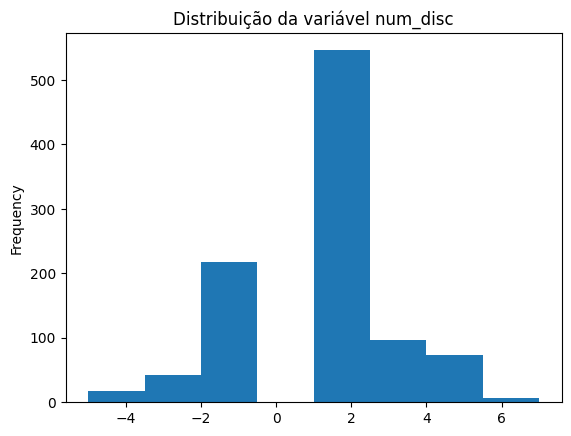

In [68]:
df.num_disc.plot(kind='hist', bins=8, title='Distribuição da variável num_disc')
plt.show()

In [ ]:
# dump(df, './data/04_aula_df_final')

['./data/df_aula_04_final']